In [190]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [191]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================

df = pd.read_csv("ecommerce_reviews.csv")
df['Review_Date'] = pd.to_datetime(df['Review_Date'])
df.set_index("Review_Date",inplace=True)
df.head(5)

,Review_ID,Product_Name,Category,Brand,Price,Rating,Review_Text,Verified_Purchase,Helpful_Votes,Review_Length,Discount_Percentage
Review_Date,,,,,,,,,,,
2023-04-15,1,PS5,Gaming,Samsung,37206.75,3,It's decent. Nothing special but works fine. C...,True,456,106,50
2024-06-01,2,Refrigerator,Electronics,Lenovo,2073.24,2,Broken on arrival. Very upset. But course act ...,True,287,79,15
2023-06-13,3,Gaming Headset,Gaming,Lenovo,11411.81,4,Amazing product! Exceeded my expectations. Hig...,True,174,154,20
2023-12-19,4,iPhone 13,Smartphones,HP,5559.41,4,Superb product. Great customer service too. Va...,True,413,124,0
2023-10-28,5,Mechanical Keyboard,Gaming,OnePlus,6678.90,5,Great quality and fast delivery. Very satisfie...,True,316,96,25


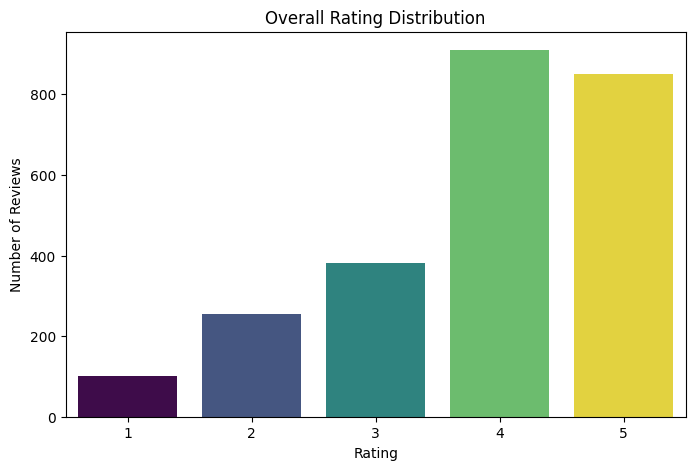

In [192]:
# =====================================================
# 1. Rating Analysis
# =====================================================

# Overall Rating Distribution:
plt.figure(figsize=(8,5))

sns.countplot(x='Rating', data=df, hue='Rating', palette='viridis', legend=False)
plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

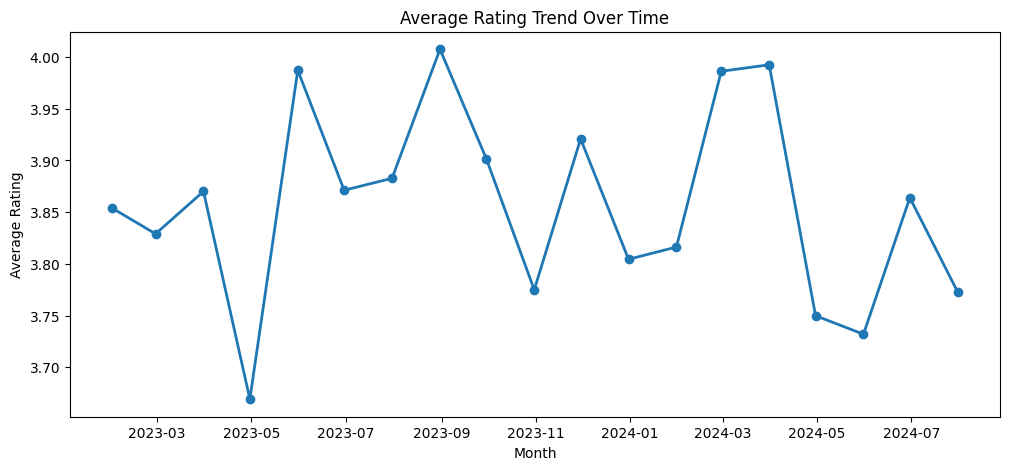

In [193]:
# Rating Trend Over Time:
monthly_rating = df["Rating"].resample("ME").mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_rating.index, monthly_rating.values, marker="o", linewidth=2)
plt.title("Average Rating Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.show()

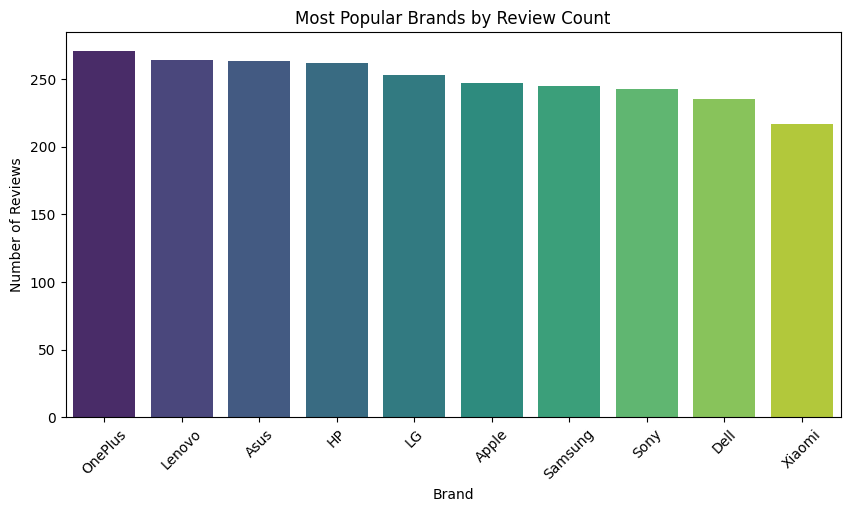

In [194]:
# =====================================================
# 2. Brand Insights
# =====================================================

# Most Popular Brands (Review Count)
brand_count = df['Brand'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=brand_count.index, y=brand_count.values,
            hue=brand_count.index, palette="viridis", legend=False)
plt.title("Most Popular Brands by Review Count")
plt.xlabel("Brand")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

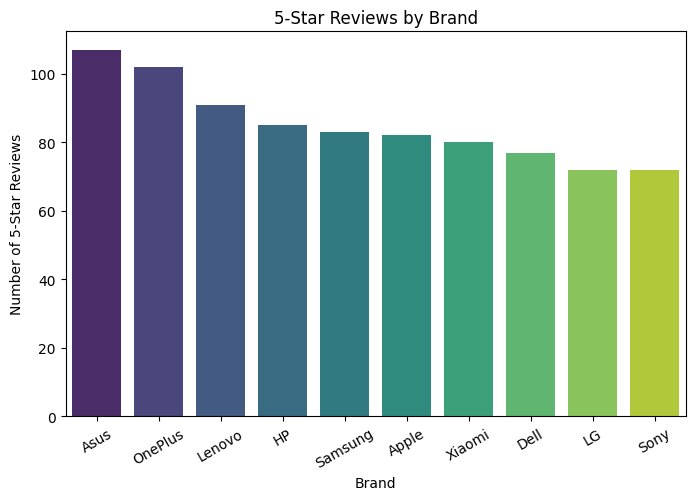

In [195]:
# 5-Star Reviews by Brand
five_star = df[df["Rating"] == 5]
five_starbrand = five_star["Brand"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(x=five_starbrand.index, y=five_starbrand.values,
            hue=five_starbrand.index, palette='viridis', legend=False)
plt.title("5-Star Reviews by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of 5-Star Reviews")
plt.xticks(rotation=30)
plt.show()

In [196]:
# Brand-wise Average Rating
brand_rating = df.groupby("Brand")["Rating"].mean().sort_values(ascending=False)
brand_rating

Brand
Xiaomi     3.935484
Asus       3.916350
OnePlus    3.915129
Samsung    3.902041
Dell       3.868085
Apple      3.854251
HP         3.843511
Lenovo     3.821970
Sony       3.794239
LG         3.770751
Name: Rating, dtype: float64

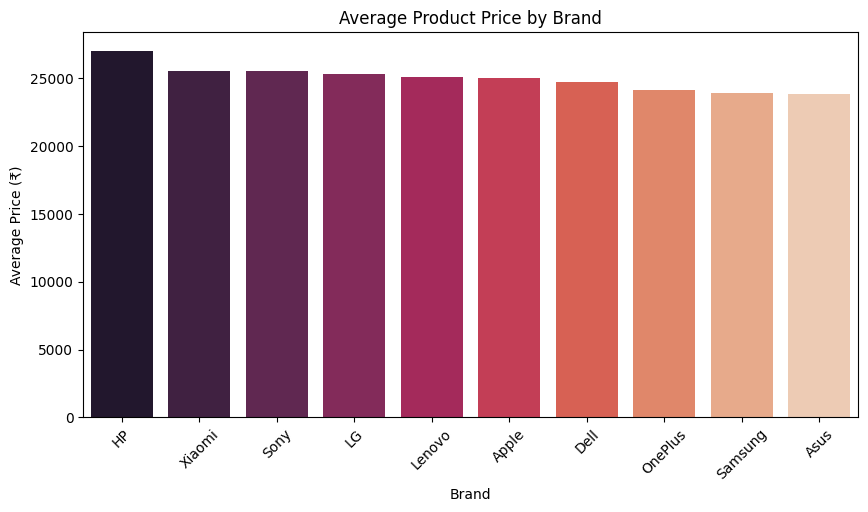

In [197]:
# Brand-wise Average Product Price
brand_price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=brand_price.index, y=brand_price.values,
            hue=brand_price.index, palette="rocket", legend=False)
plt.title("Average Product Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)
plt.show()

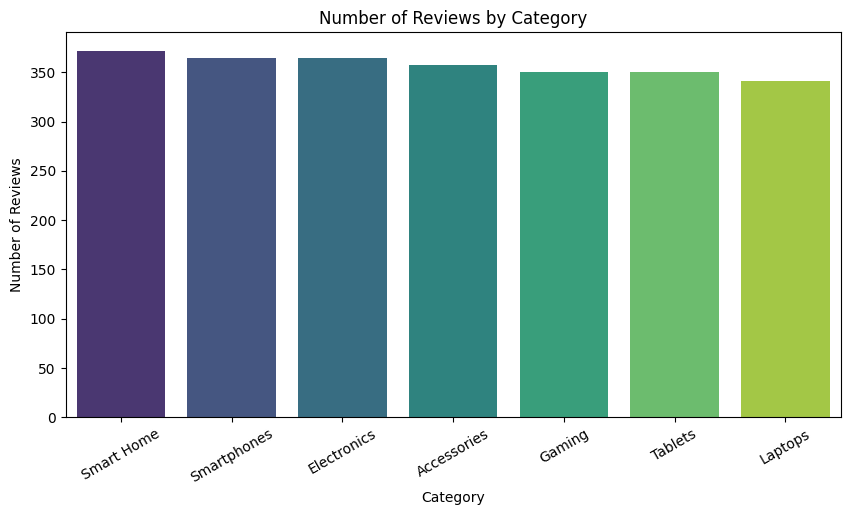

In [198]:
# =====================================================
# 3. Category Insights
# =====================================================

# Number of Reviews by Category
category_review = df["Category"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=category_review.index, y=category_review.values,
            hue=category_review.index, palette="viridis", legend=False)

plt.title("Number of Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=30)
plt.show()

In [199]:
# Category-wise Average Rating
category_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)
category_rating

Category
Electronics    3.879452
Smart Home     3.879032
Gaming         3.874286
Tablets        3.874286
Accessories    3.859944
Laptops        3.844575
Smartphones    3.819178
Name: Rating, dtype: float64

D:\Temp\ipykernel_10512\672991679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Discount_Percentage',


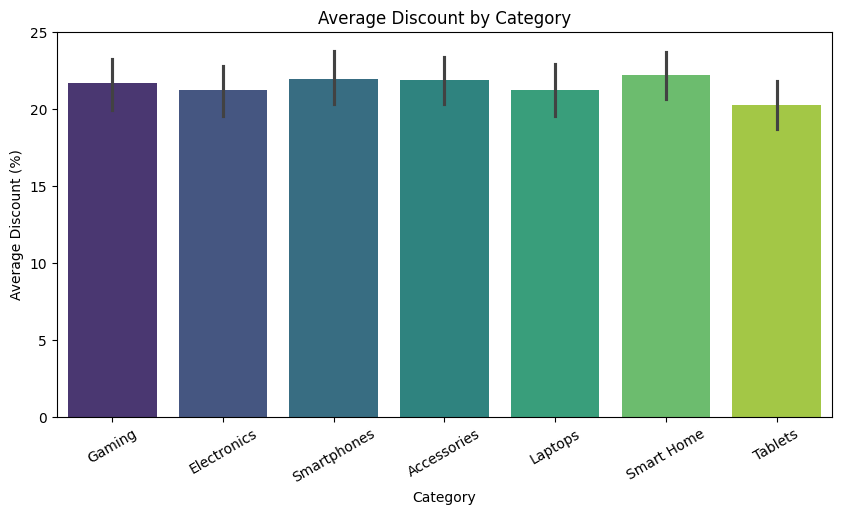

In [200]:
# Category-wise Average Discount
plt.figure(figsize=(10,5))

sns.barplot(x='Category', y='Discount_Percentage',
            data=df, estimator='mean', palette="viridis")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=30)
plt.show()

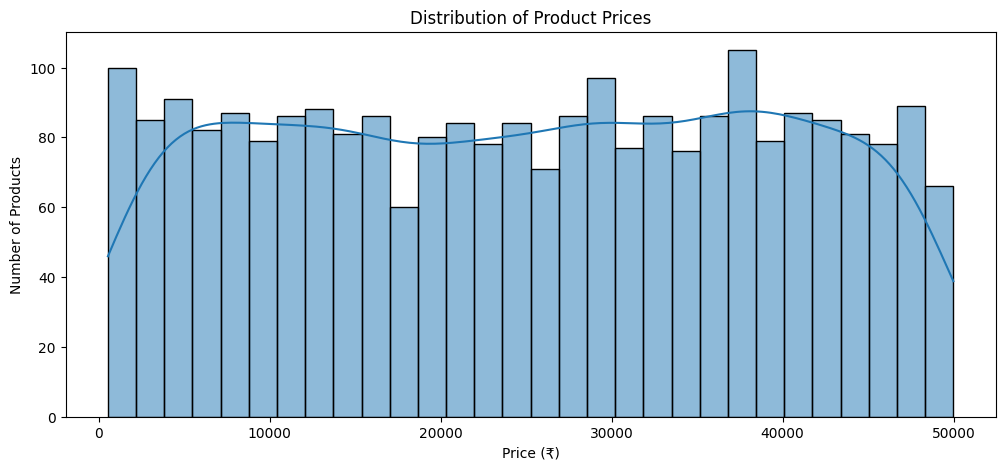

In [201]:
# =====================================================
# 4. Price Analysis
# =====================================================

# Distribution of Product Prices
plt.figure(figsize=(12,5))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of Product Prices")
plt.xlabel("Price (₹)")
plt.ylabel("Number of Products")
plt.show()

D:\Temp\ipykernel_10512\3728711264.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating', y='Price', data=df,


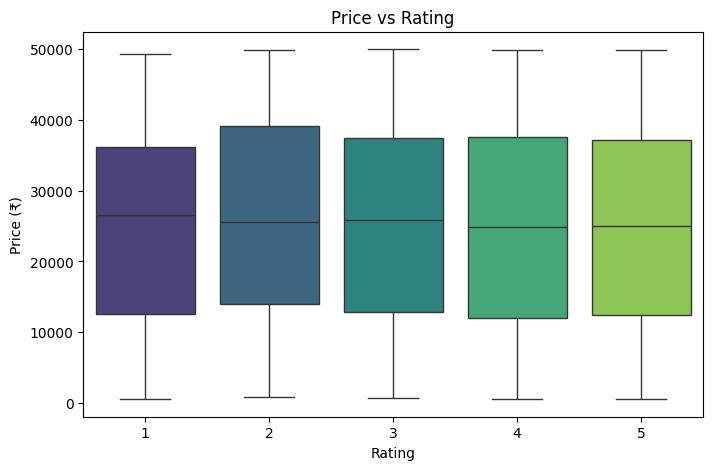

In [202]:
# Price vs Rating
plt.figure(figsize=(8,5))

sns.boxplot(x='Rating', y='Price', data=df,
            palette="viridis", legend=False)

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (₹)")
plt.show()

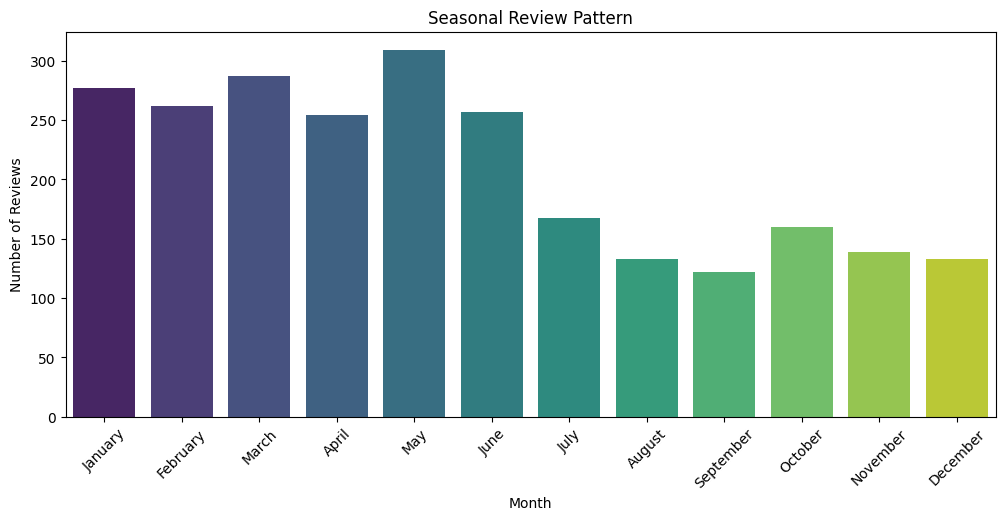

In [203]:
# =====================================================
# 5. Time-based Analysis
# =====================================================

# Seasonal Review Pattern
df["Month"] = df.index.month_name()

seasonal_reviews = (
    df.groupby("Month")["Review_ID"].count()
      .reindex([
          "January","February","March","April","May","June",
          "July","August","September","October","November","December"
      ])
)

plt.figure(figsize=(12,5))

sns.barplot(x=seasonal_reviews.index,
            y=seasonal_reviews.values,
            hue=seasonal_reviews.index,
            palette="viridis",
            legend=False)

plt.title("Seasonal Review Pattern")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

D:\Temp\ipykernel_10512\4147776819.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Verified_Purchase',


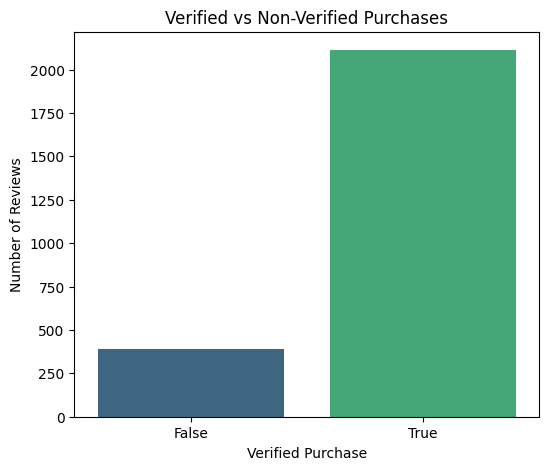

In [204]:
# =====================================================
# 6. Review Behavior
# =====================================================

# Verified vs Non-Verified Purchases
plt.figure(figsize=(6,5))

sns.countplot(x='Verified_Purchase',
              data=df,
              palette="viridis")

plt.title("Verified vs Non-Verified Purchases")
plt.xlabel("Verified Purchase")
plt.ylabel("Number of Reviews")
plt.show()

D:\Temp\ipykernel_10512\52704489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Verified_Purchase',


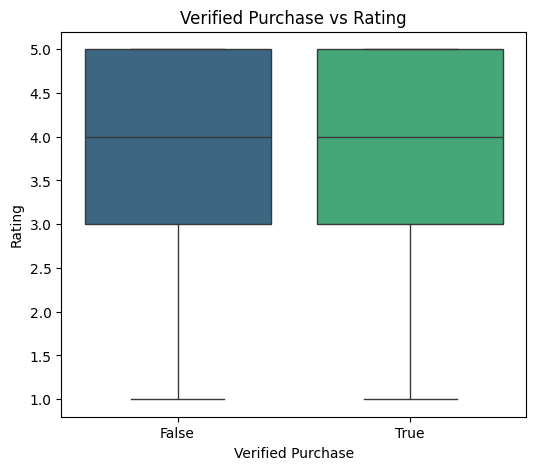

In [205]:
# Verified Purchase vs Rating
plt.figure(figsize=(6,5))

sns.boxplot(x='Verified_Purchase',
            y='Rating',
            data=df,
            palette="viridis")

plt.title("Verified Purchase vs Rating")
plt.xlabel("Verified Purchase")
plt.ylabel("Rating")
plt.show()

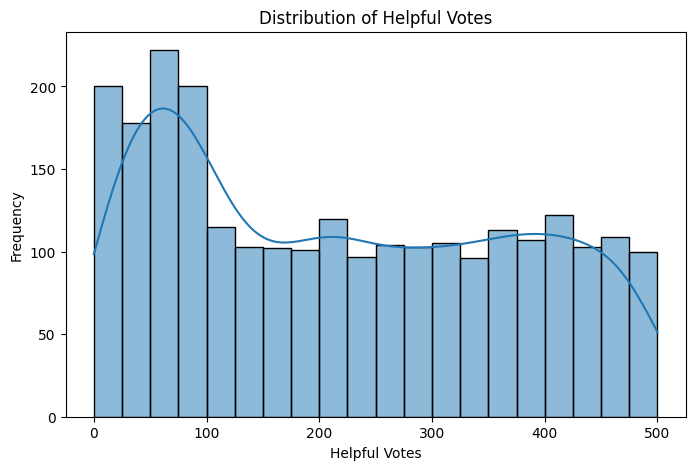

In [206]:
# Helpful Votes Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Helpful_Votes'], bins=20, kde=True)

plt.title("Distribution of Helpful Votes")
plt.xlabel("Helpful Votes")
plt.ylabel("Frequency")
plt.show()